# 02 — Exploratory Analysis

**Purpose (workflow steps 4-6):** understand what's actually going on in the reviews well enough to
draft a defensible issue taxonomy — *before* touching sentiment scoring or classification. Every
analysis below exists to answer a specific question, not to demonstrate a technique.

This notebook does **not** decide the final taxonomy on its own. Word frequency stats surface
candidates; the manual reading sections at the end are what actually confirms or kills them. Both are
required — frequency alone over/under-counts phrasing variants, and manual reading alone doesn't scale
or prove how common something is.

## Import

In [1]:
import sys
import re
from pathlib import Path
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.text_utils import tokenize, top_ngrams, plot_ngrams, rating_group

## Load Cleaned Dataset

Loading from `data/interim/`, the file saved at the end of `01_data_audit.ipynb`, rather than
re-running `clean_reviews()` here. If this cell fails with a `FileNotFoundError`, go run notebook 01
through its "Save Cleaned Dataset" cell first.

In [2]:
INTERIM_PATH = (
    PROJECT_ROOT
    / "data"
    / "interim"
    / "bca_mobile_reviews_clean.csv"
)

df = pd.read_csv(INTERIM_PATH, parse_dates=["review_date"])

df["review_length"] = df["review_text"].str.split().str.len()

print(f"Loaded: {len(df):,} rows")
print(f"Date range: {df['review_date'].min()} -> {df['review_date'].max()}")
df.head()

Loaded: 5,000 rows
Date range: 2026-05-01 07:42:02 -> 2026-08-18 00:27:56


,review_id,rating,review_date,review_text,thumbs_up,review_length
0,2396eda7-a8ad-4bb5-bee4-83c8fce035cb,5,2026-05-01 07:42:02,"Carayah beda sama you tube k,beda di youtube e...",0,27
1,1382e567-d25e-46b2-9456-99f49c901bf7,5,2026-05-01 09:34:18,puas dengan BCA mobile,0,4
2,60373c7b-5f7c-4725-93f5-b0877bd767e9,1,2026-05-01 09:53:40,TOLONG APK BCA MOBILE BANKING NYA DIPERBAIKI L...,0,28
3,042470e3-1eae-4f92-9830-1ed331edd839,1,2026-05-01 10:06:17,top up flazz transaksi gagal di tapi saldo rek...,0,17
4,9a32e854-5285-4fe1-83c5-df0341364c1d,1,2026-05-01 10:21:09,"aplikasi macam apa ini,di daftarin berkali kal...",0,26


## Define Rating Groups

Splitting into **negative (1-2 stars)**, **neutral (3 stars)**, and **positive (4-5 stars)** rather
than working star-by-star. Product-issue signal lives almost entirely in the negative group; 3-star
is kept separate because it often reflects "it works but X is annoying" rather than a hard complaint,
which is a different kind of insight than 1-2 star failures.

## Review Length by Rating Group

**Business question:** do dissatisfied customers write more detailed reviews than satisfied ones?
If so, negative reviews are a richer source of specific, actionable complaints (not just "bad app"),
and it's worth prioritizing them for the manual reading pass below.

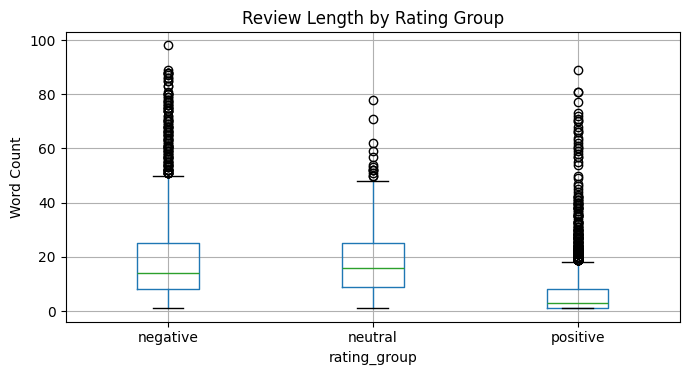

,count,mean,50%,max
rating_group,,,,
negative,2313.0,18.812797,14.0,98.0
neutral,332.0,18.253012,16.0,78.0
positive,2355.0,6.677282,3.0,89.0


In [3]:
df["rating_group"] = df["rating"].apply(rating_group)

df["rating_group"].value_counts()
fig, ax = plt.subplots(figsize=(7, 4))
df.boxplot(column="review_length", by="rating_group", ax=ax)
ax.set_title("Review Length by Rating Group")
ax.set_ylabel("Word Count")
plt.suptitle("")
plt.tight_layout()
plt.show()

df.groupby("rating_group")["review_length"].describe()[["count", "mean", "50%", "max"]]

## Word Frequency Setup

**Method choice:** plain normalized token frequency (unigrams + bigrams) over a hand-curated Indonesian
stopword list, rather than TF-IDF, embeddings, or a topic model at this stage.

Why: the goal right now is *readable, auditable* candidate terms a human can sanity-check against
actual reviews in minutes. Frequency counts are directly interpretable ("this word appeared 340 times
in negative reviews"); a topic model's output ("topic 4: weight 0.12 on 'buka', 0.09 on 'terus'...")
is not, and would be over-engineering for what is still a data-exploration step, not a deployed model.

The stopword list below is intentionally visible and editable in this notebook (not hidden in an
external library) — if a real complaint term is being filtered out, or a generic term is slipping
through, it should be obvious and fixable in two seconds.

In [4]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))



**Note:** if the code above throws a `TypeError` on the `list[str]` type hint, your Python version
is older than 3.9 — replace it with `List[str]` from `typing`, or just drop the hint.

## Top Terms in Negative Reviews (1-2 stars)

These are the most frequent issue-related terms among negative reviews — the direct input for
building the issue taxonomy in the next notebook.

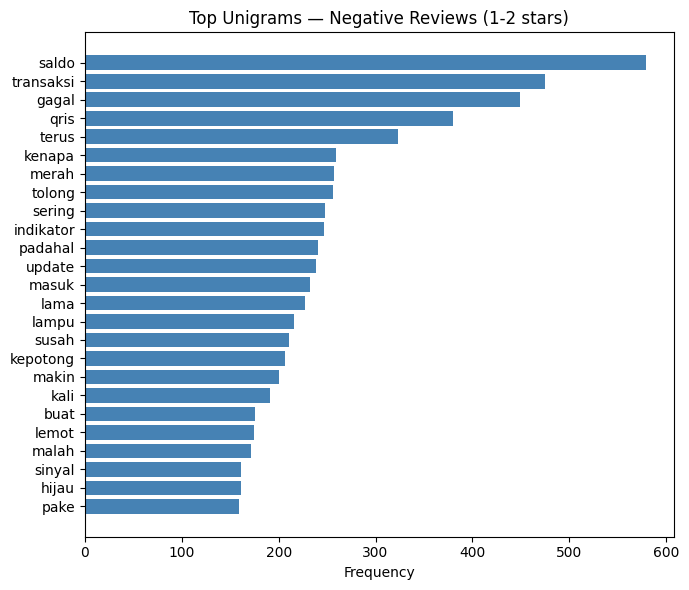

In [5]:
negative_text = df[df["rating_group"] == "negative"]["review_text"]

neg_unigrams = top_ngrams(negative_text, n=1, top_k=25)
neg_bigrams = top_ngrams(negative_text, n=2, top_k=25)

plot_ngrams(neg_unigrams, "Top Unigrams — Negative Reviews (1-2 stars)")

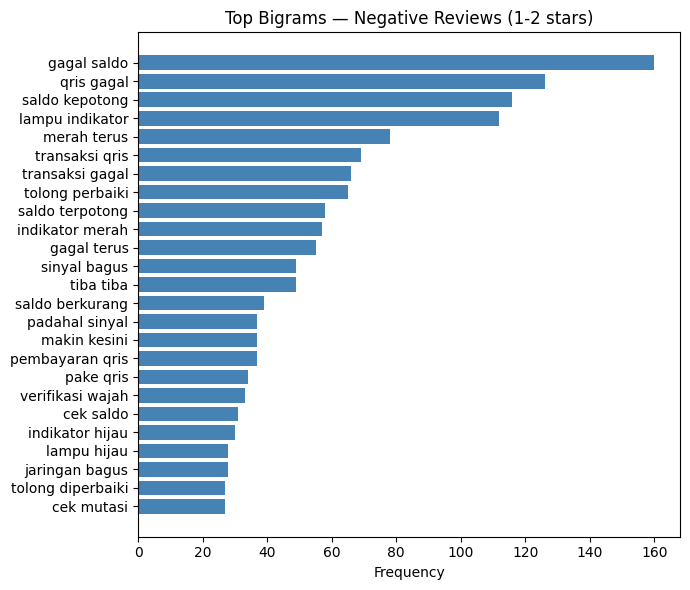

In [6]:
plot_ngrams(neg_bigrams, "Top Bigrams — Negative Reviews (1-2 stars)")

## Negative vs. Positive: What's Actually Distinctive?

Raw negative-review frequency alone can be misleading — a word might be common in negative reviews
simply because it's common everywhere (e.g. generic app vocabulary that slipped past the stopword
list). Comparing against positive-review frequency filters those out and leaves terms that are
genuinely tied to dissatisfaction.

**Method:** for each term, compute its share of negative mentions vs. positive mentions
(`negative_count / (negative_count + positive_count)`), restricted to terms that appear at least
`MIN_COUNT` times total so rare/noisy terms don't dominate the ranking. This is a simple, transparent
ratio — not a statistical test — and should be read as "candidates worth checking," not proof.

In [7]:
MIN_COUNT = 5  # lower this if the dataset is small; raise it if the top list is noisy

positive_text = df[df["rating_group"] == "positive"]["review_text"]

neg_counts = Counter()
for text in negative_text:
    neg_counts.update(tokenize(text))

pos_counts = Counter()
for text in positive_text:
    pos_counts.update(tokenize(text))

all_terms = set(neg_counts) | set(pos_counts)

rows = []
for term in all_terms:
    n, p = neg_counts.get(term, 0), pos_counts.get(term, 0)
    total = n + p
    if total >= MIN_COUNT:
        rows.append({
            "term": term,
            "negative_count": n,
            "positive_count": p,
            "total": total,
            "negative_share": n / total,
        })

columns = ["term", "negative_count", "positive_count", "total", "negative_share"]

distinctive = (
    pd.DataFrame(rows, columns=columns)
    .sort_values(["negative_share", "total"], ascending=[False, False])
    .head(30)
    .reset_index(drop=True)
)

if distinctive.empty:
    print(
        f"No terms met MIN_COUNT={MIN_COUNT} (dataset may be small here, "
        "or try lowering MIN_COUNT)."
    )

distinctive

,term,negative_count,positive_count,total,negative_share
0,sampah,34,0,34,1.0
1,ribu,27,0,27,1.0
2,malu,24,0,24,1.0
3,perbaikan,24,0,24,1.0
4,kaga,22,0,22,1.0
5,benerin,21,0,21,1.0
6,restart,21,0,21,1.0
7,signal,21,0,21,1.0
8,alasan,20,0,20,1.0
9,kocak,19,0,19,1.0


## Trend: Negative Review Volume Over Time

Notebook 01 already covered overall monthly volume/rating. This looks specifically at whether the
*negative* review volume is flat, rising, or spiking in particular months — flat noise vs. a real
emerging problem (e.g. tied to an app update) look very different here and matter for prioritization
later.

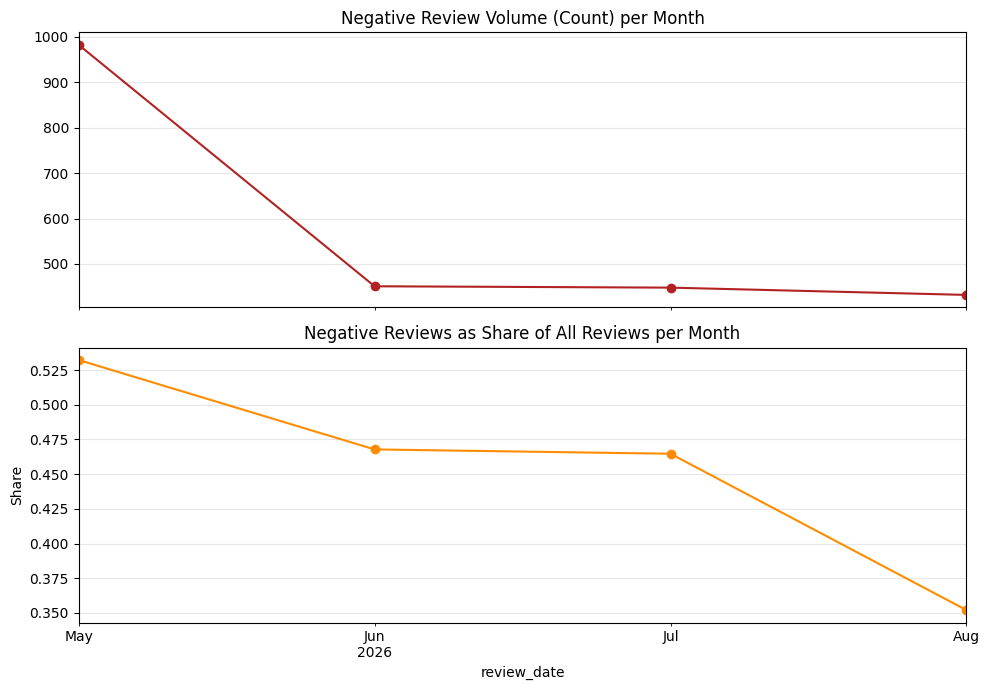

In [8]:
monthly_negative = (
    df[df["rating_group"] == "negative"]
    .set_index("review_date")
    .resample("ME")
    .size()
)

monthly_negative_share = (
    df.set_index("review_date")["rating_group"]
    .eq("negative")
    .resample("ME")
    .mean()
)

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

monthly_negative.plot(ax=axes[0], marker="o", color="firebrick")
axes[0].set_title("Negative Review Volume (Count) per Month")
axes[0].grid(alpha=0.3)

monthly_negative_share.plot(ax=axes[1], marker="o", color="darkorange")
axes[1].set_title("Negative Reviews as Share of All Reviews per Month")
axes[1].set_ylabel("Share")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Why both charts:** raw count can rise just because total review volume rose. Share-of-total
controls for that — a real spike in dissatisfaction shows up in the *share* chart even if overall
volume is flat or growing.

## Manual Reading — Longest Negative Reviews

Short low-star reviews ("aplikasi jelek", "parah") confirm dissatisfaction but rarely explain the
specific problem. Longer negative reviews are far more likely to describe *what actually happened*
step by step, which is exactly what's needed to write real taxonomy category definitions rather than
guessing from single words out of context.

Sorting by length (not random sampling) here is deliberate — this section is for taxonomy building,
not for an unbiased read of "what negative reviews typically look like" (notebook 01 already did that
with a random sample).

In [9]:
pd.set_option("display.max_colwidth", 400)

df[df["rating_group"] == "negative"].sort_values(
    "review_length", ascending=False
)[["review_date", "rating", "review_length", "review_text"]].head(30)

,review_date,rating,review_length,review_text
2999,2026-07-07 11:38:08,1,98,"Pelayanan bca mkin kacau/gak profesional, dl kl ktmau ctk buku tbgn, gnt kartu atm gak prl pakai ambil no antrian, tggl ngeprint di mesinny/dilayani 1 staff yg khss mlyni di msn ctk bk, ctk krt atm, bhkn sstpmpun bs mlyni, skrng mlh pk ambl no antrian alhasil semua nsbh numpuk jd 1 dr yg mau ke CS, ctk bk, gnt krt atm, dll, nah kl sdh bgt otmts antrian jd smkn pnjng, lm bg nsbh, ini nmnya kerj..."
4020,2026-08-08 11:40:22,1,89,"1. ganti nomor SIM card ke cabut bentar aja di pasang di hp yg sama malah ga bisa tulisannya kudu ke ATM mobile BCA buat login kembali mbanking BCA. ribet banget SABTU MGGU LGI ,SOP sistem terlalu alay. 2.tiap kali mau bayar qris tanda hijau lama banget munculnya di saat mau bayar atau pas ke distrek bolak balik WA/lainnya selama 2 detik aja ngerefresh tu tanda hijau kanan atasnya jadi biru te..."
4647,2026-08-13 14:12:10,1,88,"g suka pke bca ribet tiba"" atm sy kena status kriminal udh gtu di cabang serua Ciputat sruh pengembalian dana 300rb udh mw 2 bln g slesai"" sruh bolak balik truss uang sy g kembali 300rb org cabangny blng klo dh kebuka uang sy ada di mbangking tp ini smpe skrg atm sy blm bisa"" gmn ni bca tolong dong sy perlu pke bca soalny uang su jg msh nyangkut 300rb itu sy dtangin ke cabang mlh di oper"" ga j..."
1970,2026-06-03 19:27:16,1,88,"hari ini Tiba2 uang yg sisa di rekening BCA 40rbu lebih hilang dan tdk ad di mutasi padahal di situ ad potongan admin 14ribu jdi hrusnya masi ad sisa 30rbuan terus sisa uangnya yg lain hilang entah ke mana, ini BCA gimana yahh 😡 Nominalnya memang ngak seberapa tapi 30rbu itu msih sangat berguna. Mulai ragu pake BCA klau sistemnya gini, untung blum isi bnyak, gimana klau sdh isi bnyak ketarik s..."
670,2026-05-13 21:29:11,1,88,"Parah si BCA, Jelas² ket Transaksi nya gagal tap saldo tetep ke pootong. jadi gini crita nya gaes, gue beli Quota di my XL parlyment nya gw pake QRIS, Sampe 4x gw QRIS traksaksi nya gagal dan QUOTA pun ga terbayar dong, Tapi tiba-tiba ada notif dari BCA ada pengeluaran Pembayaran 4x melalui QRIS, nah saldo nya ke mana, di my XL gak ada quota juga gak terbayar dan si saldo BCA juga ilang duit n..."
2709,2026-06-27 13:56:13,1,88,kesal kali saya SM bank BCA ini.ENTH kemana data nasabah yang 6 bulan tidak aktif bisa dpt di tangan pihak ke3. smpai akhr ny dia tau smua data saya .dan terpaksa ya hrs blokir rekening mandiri saya semntra dmn skrng saya kesusahan.blom BS guna kn living sya . jngn nm nya bank internasional aj . Bertanggungjawab sikit SM data nasabah. dia berbasis kartu digital BCA kt ny.smpai BRP KL saya dihu...
641,2026-05-13 21:10:44,1,87,"wowwww, sempat panik gr2 beli paket quota internet pake qris di keterangan gagal karena gangguan akhir nya aq coba lagi jd total melakukan pembayaran pake qris sebanyak 2x tapi tetap di keterangan tulisan nya gagal dan abis itu iseng cek saldo whattt uang gw berkurang sebanyak nominal yg mau aq isi tadi mana 2x aq melakukan transaksi qris nya aduhhh. tolong donk bca jgn buat shick shock. gw mi..."
204,2026-05-07 10:08:47,1,86,"isi pulsa ngak ke kirim ngak ada bukti transaksi berhasil tapi saldo udah kepotong, udah bikin laporan disuruh nunggu 1 hari udah satu hari ngak ada progres, saya telfon lagi pagi nya ditanya gmna prosesnya malah udah di closed masalah belom selesai tapi udah di tutup saldo ngak balik, pas saya telfon malah disuruh bikin laporan lagi udah dibikin tuh trus gmna dari pihak bca tuh kerja kaga sih..."
3698,2026-07-29 20:04:52,1,86,"gua mau bikin buat payroll, niatnya pake apk aja simple, giliran masukin foto gagal mulu, katanya pencahayaan musti baik & gak buram, padahal gua udah di luar rumah posisi siang hari. gua ngalahin pergi ke bca terdekat, bikin atm baru, n niatnya sekalian daftar m banking tp mau masukin datanya ntar aja kalo sudah di rumah. eh masih sama masukin foto gagal mulu, ada alasan buram lah, sinyal hil..."
3999,2026-08-07 14:46:45,1,85,kantor BCA tanah Abang lemot .. nangg

## Candidate Issue Taxonomy (Derived from Manual Reading + Frequency Analysis)

Unlike the placeholder version of this cell, the categories below are grounded in the actual
top unigrams/bigrams above and the 30 longest negative reviews read manually. Each has real quote
evidence, not assumed banking-app boilerplate. Two categories (`transaction_failed_balance_deducted`
and `indicator_light_stuck`) are kept separate even though they co-occur often, because they imply
different fixes and different urgency — one is a UI/state bug, the other is money actually
disappearing. Whether they're *always* co-occurring or genuinely independent is worth checking with
real counts in 03.

| Category | Working definition | Real quote evidence |
|---|---|---|
| `transaction_failed_balance_deducted` | QRIS/transfer/top-up reported as failed, but balance is still deducted and not refunded. | *"transaksi nya gagal tap saldo tetep ke pootong"*, *"qris gagal tapi saldo kepotong... Rp 225.000"* |
| `indicator_light_stuck` | The in-app payment-readiness indicator (red/green light) gets stuck red or is slow to turn green, blocking or delaying QRIS scans. | *"nunggu indikator hijau tapi yg muncul indikator warna merah aja"*, *"lampu tetap merah dan tak kunjung hijau"* |
| `unexplained_deduction` | Balance decreases with no matching entry in mutasi (transaction history), not tied to a specific attempted transaction. | *"saldo tb2 terpotong gktau uangnya kmna. dn di mutasi jg tdk ada ktrangan"*, *"potongan gak jelas"* |
| `face_verification_failure` | Face/biometric verification (login, registration, OTP) repeatedly fails, especially on older phones. | *"verivikasi wajah sangat susah"*, *"Verifikasi Wajah sangat sulit di hp lawas Realme C2"* |
| `login_otp_access` | Cannot log in, or OTP/access process is broken or overly burdensome (SIM swap, pulsa-dependent OTP). | *"gnt hp yg sama malah ga bisa... kudu ke ATM"*, *"minta kode otp aja pulsa habis terus"* |
| `app_performance` | App is slow, errors out, or needs reinstall/restart, not clearly tied to QRIS/indicator. | *"sangat sering LEMOT banget"*, *"transaksi eror gk bisa ambil uang"* |
| `maintenance_downtime` | Scheduled maintenance at inconvenient times (often unannounced), blocking transactions. | *"SERING UPDATE PEMELIHARAAN MULU TENGAH MALAM"* |
| `customer_service` | CS/branch/call-center complaints go unresolved or get looped without response. | *"lapor ke WhatsApp halo BCA tapi ga ada respon"*, *"cs selalu lempar tangan"* |
| `ui_ux_regression` | Post-update interface changes reduce usability (lost features, confusing layout). | *"setelah update bukanny tambah memudahkan... malah jadi tambah membingungkan"* |
| `device_compatibility` | App reports device/version incompatibility, can't install/update. | *"versi hp 12 kenapa jadi ga kompetebel"* |

**Watch list, not yet a category:** standalone "sinyal" (signal) complaints appeared a couple of
times without the indicator-light phrasing (*"suka hilang sinyal"*). Worth checking in 03 whether
this is frequent enough on the full dataset to warrant an 11th category, or whether it's just part
of how people describe the indicator issue.

## Findings & Next Steps

**Review length**
- Yes — negative reviews average 18.8 words vs 6.7 for positive (median 14 vs 3). Confirms negative
  reviews are the right place to focus manual reading effort; positive reviews are mostly one-word
  praise ("bagus", "mantap") and carry little product signal.

**Word frequency**
- Top negative unigrams: `saldo`, `transaksi`, `gagal`, `qris`, `indikator`, `merah` — money/QRIS
  failure and the indicator-light bug dominate by a wide margin over any other theme.
- Top negative bigrams confirm this isn't noise: `gagal saldo`, `qris gagal`, `saldo kepotong`,
  `lampu indikator`, `transaksi qris`, `indikator merah` are the top 10.
- Distinctive-terms table (negative_share = 1.0 for the top 30) shows these aren't just generic
  words that happen to appear in negative reviews more often — words like `sampah`, `restart`,
  `signal`, `benerin`, `mengecewakan` essentially never appear in positive reviews at all.

**Trend**
- Negative review volume and share are both *declining* over the observed period: negative share
  drops from ~53% (May) to ~35% (August), tracking the rising average rating from notebook 01
  (2.77 → 3.46). This should be stated plainly rather than defaulting to problem-framing — whatever
  is driving complaints looks like it's improving, not worsening, over these four months. Worth
  checking in 03 whether the QRIS/indicator issue specifically follows this same declining pattern,
  or whether it's flat while something else improved.

**Taxonomy**
- 10 categories drafted from real quote evidence (see table above), dominated by two related-but-
  distinct financial/technical bugs: `transaction_failed_balance_deducted` and
  `indicator_light_stuck`.
- Watch item: standalone signal/connectivity complaints — may or may not warrant their own category,
  decide after checking frequency in 03.

**Decision for 03_issue_classification.ipynb**
- All 10 categories have enough direct evidence to write keyword rules for. Build a rule-based,
  multi-label classifier (interpretable, auditable — consistent with the project's method choices
  so far), then measure: per-category count and share of negative reviews, negative-rate (does
  mentioning this term correlate with low rating, as a sanity check), trend over time per category,
  and — importantly — what share of negative reviews match *no* category, since that number tells us
  how complete this taxonomy actually is.